In [1]:
!git clone https://github.com/AleksandraJuchniewicz/Analiza-danych.git

Cloning into 'Analiza-danych'...


In [2]:
%cd Analiza-danych
!ls

c:\Users\kotle\OneDrive\Pulpit\studia\analityka\semestr 3\Analiza danych python\Analiza-danych\Analiza-danych


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
pip install pandas

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.1 MB 3.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/11.1 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.1 MB 4.3 MB/s eta 0:00:02
   -------------- ------------------------- 3.9/11.1 MB 4.4 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.1 MB 4.6 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.1 MB 4.9 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.1 MB 4.9 MB/s eta 0:00:01
   -------------------------------- ------- 8.9/11.1 MB 5.2 MB/s eta 0:00:01
   ------------------------------------- -- 10.5/11.1 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 5.5 MB/s  0:00:02
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----- ------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:

pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd

df_d = pd.read_csv("bdl_data_dewastacja_.csv")
df_poz=pd.read_csv("bdl_data_pozar_.csv")
df_gaz=pd.read_csv("bdl_data_Zangaz_.csv")
df_pyl=pd.read_csv("bdl_data_Zanpyl_.csv")
df_zat=pd.read_csv("bdl_data_zatrudnienie_.csv")
df_il=pd.read_csv("bdl_datailosc_2024_.csv")
df_war=pd.read_csv("bdl_datawartosc_2024_.csv")
df_las=pd.read_csv("bdl_powlas_2024_.csv")
df_lasch=pd.read_csv("bdl_powlaschro_2024_.csv")

In [8]:
import numpy as np


In [14]:
import math


In [19]:
dfs = [df_d, df_poz, df_gaz, df_pyl, df_zat, df_il, df_war, df_las, df_lasch]
new_names = [
    "Dewastacja",
    "Pozary",
    "Za_gaz",
    "Za-pyl",
    "Zatrudnienie",
    "Ilosc",
    "Wartosc",
    "P_lasy",
    "P_lasy_ch"
]
for df, new_name in zip(dfs, new_names):
    df.rename(columns={"Value": new_name}, inplace=True)
for i, df in enumerate(dfs, start=1):
    print(f"df{i}:", df.columns.tolist())

df1: ['Region', 'Year', 'Dewastacja']
df2: ['Region', 'Year', 'Pozary']
df3: ['Region', 'Year', 'Za_gaz']
df4: ['Region', 'Year', 'Za-pyl']
df5: ['Region', 'Year', 'Zatrudnienie']
df6: ['Region', 'Year', 'Ilosc']
df7: ['Region', 'Year', 'Wartosc']
df8: ['Region', 'Year', 'P_lasy']
df9: ['Region', 'Year', 'P_lasy_ch']


In [20]:
for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {df['Year'].min()}–{df['Year'].max()}")

df1: 2005–2020
df2: 2009–2024
df3: 1998–2024
df4: 1996–2024
df5: 2010–2024
df6: 2009–2024
df7: 2009–2024
df8: 1998–2024
df9: 1998–2024


In [21]:
for i in range(len(dfs)):
    dfs[i] = dfs[i].loc[
        (dfs[i]["Year"] >= 2016) &
        (dfs[i]["Year"] <= 2020)
    ].copy()

for i, df in enumerate(dfs, start=1):
    print(f"df{i}: {sorted(df['Year'].unique())}")

df1: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df2: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df3: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df4: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df5: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df6: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df7: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df8: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
df9: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [22]:
from functools import reduce

df_all = reduce(
    lambda left, right: left.merge(
        right,
        on=["Region", "Year"],
        how="inner"
    ),
    dfs
)

print(df_all.shape)
print(df_all.head())

(80, 11)
        Region  Year  Dewastacja  Pozary      Za_gaz  Za-pyl  Zatrudnienie  \
0  MAŁOPOLSKIE  2016        54.4    97.0  10059451.0  2067.0          50.4   
1  MAŁOPOLSKIE  2017        53.7   116.0  10927841.0  2057.0          51.3   
2  MAŁOPOLSKIE  2018        52.7   236.0  10483040.0  1841.0          52.3   
3  MAŁOPOLSKIE  2019        54.5   190.0   8996236.0  1635.0          53.5   
4  MAŁOPOLSKIE  2020        56.9   176.0   7002044.0  1088.0          53.5   

   Ilosc  Wartosc     P_lasy  P_lasy_ch  
0   22.0    469.0  202140.16   18043.51  
1   16.0    196.7  202078.00   18112.17  
2    9.0    101.0  201366.39   18143.25  
3   27.0    231.9  201241.09   18197.84  
4   18.0    198.6  201200.81   18238.77  


In [23]:
#braki
df_all.isna().sum()
#duikaty
df_all.duplicated(["Region", "Year"]).sum()

np.int64(0)

In [24]:
pip install scipy


   ---------------------------------------- 0.0/37.1 MB ? eta -:--:--
    --------------------------------------- 0.5/37.1 MB 3.0 MB/s eta 0:00:13
   - -------------------------------------- 1.6/37.1 MB 4.5 MB/s eta 0:00:08
   -- ------------------------------------- 2.4/37.1 MB 4.3 MB/s eta 0:00:09
   --- ------------------------------------ 3.1/37.1 MB 4.4 MB/s eta 0:00:08
   ---- ----------------------------------- 4.2/37.1 MB 4.3 MB/s eta 0:00:08
   ------ --------------------------------- 5.8/37.1 MB 4.8 MB/s eta 0:00:07
   ------- -------------------------------- 6.8/37.1 MB 5.0 MB/s eta 0:00:07
   -------- ------------------------------- 7.9/37.1 MB 5.0 MB/s eta 0:00:06
   --------- ------------------------------ 9.2/37.1 MB 5.2 MB/s eta 0:00:06
   ---------- ----------------------------- 10.0/37.1 MB 5.2 MB/s eta 0:00:06
   ----------- ---------------------------- 10.5/37.1 MB 5.0 MB/s eta 0:00:06
   ------------ --------------------------- 11.8/37.1 MB 4.9 MB/s eta 0:00:06
   

In [42]:
import numpy as np
from scipy.stats import t
import pandas as pd

def confidence_interval(data, confidence=0.95):
    data = data.dropna()
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    t_val = t.ppf((1 + confidence) / 2, n - 1)
    margin = t_val * std / np.sqrt(n)
    return mean, mean - margin, mean + margin, n

In [43]:
results_ilosc = []

for region, group in df_all.groupby("Region"):
    mean, low, high, n = confidence_interval(group["Ilosc"])
    results_ilosc.append({
        "Region": region,
        "Średnia Ilosc": round(mean, 2),
        "CI 95% dolna": round(low, 2),
        "CI 95% górna": round(high, 2),
        "n": n
    })

ci_ilosc = pd.DataFrame(results_ilosc).sort_values("Średnia Ilosc", ascending=False)
print(ci_ilosc)


                 Region  Średnia Ilosc  CI 95% dolna  CI 95% górna  n
11        WIELKOPOLSKIE         1576.6        245.58       2907.62  5
9             POMORSKIE         1125.0        519.58       1730.42  5
3              LUBUSKIE          804.6        280.61       1328.59  5
10  WARMIŃSKO-MAZURSKIE          356.2         53.14        659.26  5
4           MAZOWIECKIE          251.2        113.73        388.67  5
8             PODLASKIE          167.6         47.23        287.97  5
0          DOLNOŚLĄSKIE          142.6          0.25        284.95  5
12   ZACHODNIOPOMORSKIE          125.2         65.40        185.00  5
13              ŁÓDZKIE          108.0         12.59        203.41  5
2             LUBELSKIE           47.6        -14.45        109.65  5
1    KUJAWSKO-POMORSKIE           30.4         10.95         49.85  5
5           MAŁOPOLSKIE           18.4         10.04         26.76  5
14              ŚLĄSKIE           17.2          2.34         32.06  5
15       ŚWIĘTOKRZYS

In [44]:
results_wartosc = []

for region, group in df_all.groupby("Region"):
    mean, low, high, n = confidence_interval(group["Wartosc"])
    results_wartosc.append({
        "Region": region,
        "Średnia Wartosc": round(mean, 2),
        "CI 95% dolna": round(low, 2),
        "CI 95% górna": round(high, 2),
        "n": n
    })

ci_wartosc = pd.DataFrame(results_wartosc).sort_values("Średnia Wartosc", ascending=False)
print(ci_wartosc)

                 Region  Średnia Wartosc  CI 95% dolna  CI 95% górna  n
11        WIELKOPOLSKIE         17257.02       4006.70      30507.34  5
9             POMORSKIE         14531.52       6660.39      22402.65  5
3              LUBUSKIE         11741.56       1548.05      21935.07  5
10  WARMIŃSKO-MAZURSKIE          5970.50       -168.19      12109.19  5
8             PODLASKIE          2884.50        357.26       5411.74  5
4           MAZOWIECKIE          2741.58       1426.08       4057.08  5
12   ZACHODNIOPOMORSKIE          1518.34        385.30       2651.38  5
0          DOLNOŚLĄSKIE          1417.96        -64.21       2900.13  5
2             LUBELSKIE           969.60       -553.82       2493.02  5
13              ŁÓDZKIE           833.88        472.99       1194.77  5
1    KUJAWSKO-POMORSKIE           313.02        196.85        429.19  5
5           MAŁOPOLSKIE           239.44         68.95        409.93  5
14              ŚLĄSKIE           221.04         19.76        42

In [48]:
pip install matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.3 MB 2.9 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.3 MB 2.5 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.3 MB 2.2 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.3 MB 2.4 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.3 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 2.1 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.3 MB 2.5 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 2.8 MB/s eta 0:00:02
   ------------------------------- -------- 6.6/8.3 MB 3.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.4 MB/s eta 0:00:01
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


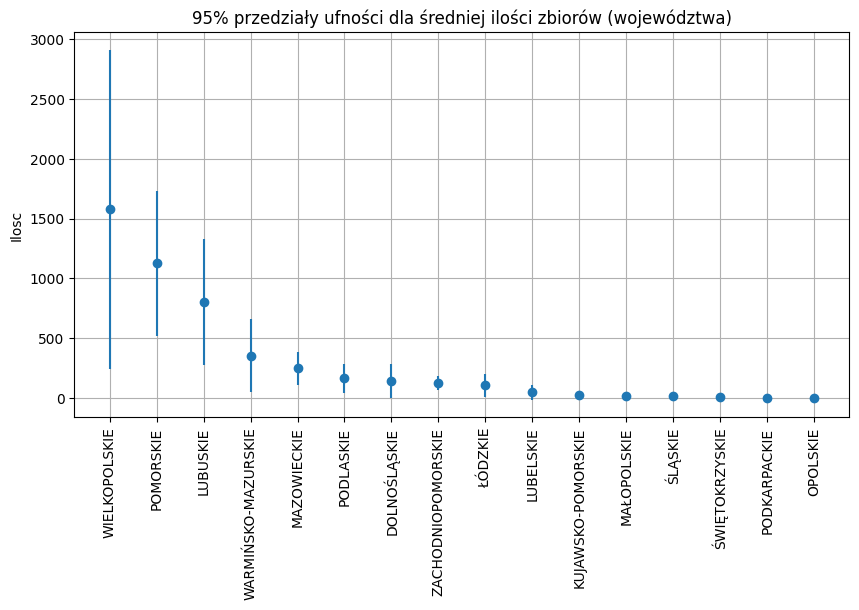

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.errorbar(
    ci_ilosc["Region"],
    ci_ilosc["Średnia Ilosc"],
    yerr=[
        ci_ilosc["Średnia Ilosc"] - ci_ilosc["CI 95% dolna"],
        ci_ilosc["CI 95% górna"] - ci_ilosc["Średnia Ilosc"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały ufności dla średniej ilości zbiorów (województwa)")
plt.ylabel("Ilosc")
plt.grid(True)
plt.show()


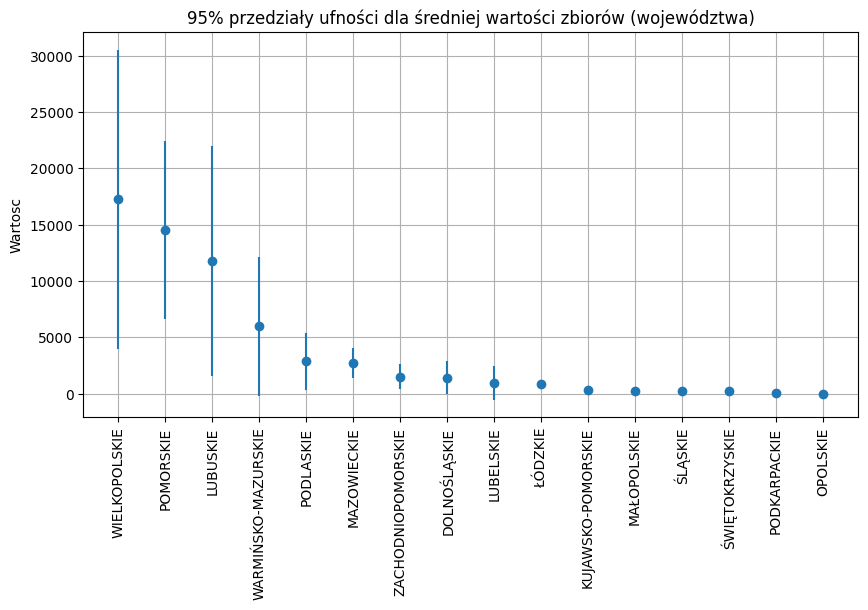

In [50]:
plt.figure(figsize=(10,5))
plt.errorbar(
    ci_wartosc["Region"],
    ci_wartosc["Średnia Wartosc"],
    yerr=[
        ci_wartosc["Średnia Wartosc"] - ci_wartosc["CI 95% dolna"],
        ci_wartosc["CI 95% górna"] - ci_wartosc["Średnia Wartosc"]
    ],
    fmt="o"
)

plt.xticks(rotation=90)
plt.title("95% przedziały ufności dla średniej wartości zbiorów (województwa)")
plt.ylabel("Wartosc")
plt.grid(True)
plt.show()
